# Basic Ray Tracing with QMC

A minimal ray tracer comparing IID (Monte Carlo) vs QMC (digital net) sampling for global illumination.  When a ray hits a surface in shadow, it scatters secondary rays to estimate indirect lighting — using QMC points instead of random directions reduces noise.

Original QMCPy demo: [`QMCPy/demos/ray_tracing.ipynb`](../../QMCPy/demos/ray_tracing.ipynb)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QMCSoftware/QMC.jl/blob/develop/demos/ray_tracing.ipynb)


**References:**
- [Scratchapixel 2.0 — Introduction to Ray Tracing](https://www.scratchapixel.com/lessons/3d-basic-rendering/introduction-to-ray-tracing/)
- [Computer Graphics from Scratch — Gabriel Gambetta](https://www.gabrielgambetta.com/computer-graphics-from-scratch/)

Parity note: this Julia notebook keeps the same ray-tracing integration target from QMCPy by comparing IID and digital-net secondary-ray sampling on the same simple room scene and then measuring image smoothness. The implementation is rewritten around the Julia rendering and dependency stack available in this repository, with a low-resolution render kept for notebook runtime.


In [1]:
using QMC
using Statistics: mean, std, var
using LinearAlgebra: norm, dot

const HAVE_PLOTS = Base.find_package("Plots") !== nothing
HAVE_PLOTS && @eval using Plots
if HAVE_PLOTS
    Plots.default(
        titlefont=Plots.font(9),
        plot_titlefont=Plots.font(11),
        left_margin=4Plots.mm,
        right_margin=8Plots.mm,
        top_margin=8Plots.mm,
        bottom_margin=5Plots.mm,
    )
end

const EPS = 1e-8
const eye = [0.0, 0.0, 0.0]  # camera at the origin


3-element Vector{Float64}:
 0.0
 0.0
 0.0

## Scene Objects

Define planes, spheres, and point lights.

In [2]:
# --- Plane ---
struct Plane
    dim::Int          # 1=x, 2=y, 3=z
    pos::Float64
    color::Vector{Float64}  # RGB ∈ [0,1]
end

function hit(p::Plane, o, u)
    k = u[p.dim]
    if k != 0
        t = (p.pos - o[p.dim]) / k
        if t > EPS
            return true, o .+ t .* u
        end
    end
    return false, nothing
end

function surface_normal(p::Plane, o, u)
    v = zeros(3)
    v[p.dim] = dot([0,0,0] |> x -> (x[p.dim]=1; x), u) < 0 ? -1.0 : 1.0
    # simpler: normal always faces the incoming light
    n = zeros(3); n[p.dim] = 1.0
    if dot(n, u) < 0
        n[p.dim] = -1.0
    end
    return n
end

# --- Ball ---
struct Ball
    center::Vector{Float64}
    radius::Float64
    color::Vector{Float64}
end

function hit(b::Ball, o, u)
    q = o .- b.center
    a = dot(u, u)
    bcoef = 2 * dot(u, q)
    c = dot(q, q) - b.radius^2
    d = bcoef^2 - 4a * c
    if d > 0
        sq = sqrt(d)
        t1 = (-bcoef - sq) / (2a)
        t2 = (-bcoef + sq) / (2a)
        ts = filter(t -> t > EPS, [t1, t2])
        if !isempty(ts)
            t = minimum(ts)
            return true, o .+ t .* u
        end
    end
    return false, nothing
end

function surface_normal(b::Ball, p, u)
    v = p .- b.center
    return v ./ norm(v)
end

# --- Point Light ---
struct PointLight
    position::Vector{Float64}
    intensity::Float64
end

In [3]:
# --- Scene ---
struct Scene
    objs::Vector{Any}
    light::PointLight
    pts::Matrix{Float64}   # pre-generated QMC/IID samples
    n_rays::Int             # secondary rays per bounce
    max_depth::Int
end

function find_closest(scene::Scene, o, v)
    best_hit = false
    best_p = nothing
    best_dist = Inf
    best_obj = nothing
    for obj in scene.objs
        h, hp = hit(obj, o, v)
        if h
            d = norm(hp .- o)
            if d < best_dist
                best_hit, best_p, best_dist, best_obj = true, hp, d, obj
            end
        end
    end
    return best_hit, best_p, best_dist, best_obj
end

function obj_color(scene::Scene, obj, p, l_dir)
    n = surface_normal(obj, p, l_dir)
    c = obj.color .* scene.light.intensity .* dot(n, l_dir) / (norm(n) * norm(l_dir))
    return clamp.(c, 0.0, 1.0)
end

function trace_beam(scene::Scene, o, v, nidx, didx, depth)
    BLACK = [0.0, 0.0, 0.0]
    h, hp, _, hobj = find_closest(scene, o, v)
    if !h
        return BLACK
    end
    l = scene.light.position .- hp
    l_dist = norm(l)
    l_u = l ./ l_dist
    # Check shadow
    sh, _, sh_dist, _ = find_closest(scene, hp, l_u)
    if sh && sh_dist <= l_dist
        # In shadow — scatter secondary rays
        if depth <= 0
            return BLACK
        end
        color_total = copy(BLACK)
        for i in 0:(scene.n_rays - 1)
            ri = min(nidx + i, size(scene.pts, 1))
            di = min(didx, size(scene.pts, 2) - 1)
            theta0 = 2π * scene.pts[ri, di]
            theta1 = 2π * scene.pts[ri, di + 1]
            v_rand = [sin(theta0)*sin(theta1), sin(theta0)*cos(theta0), sin(theta1)]
            ho_n = surface_normal(hobj, hp, l_u)
            if dot(v_rand, ho_n) < 0
                v_rand = -v_rand
            end
            oc = obj_color(scene, hobj, hp, l_u)
            bounce = trace_beam(scene, hp, v_rand, ri, di + 2, depth - 1)
            color_total .+= oc .* bounce
        end
        return color_total ./ scene.n_rays
    else
        return obj_color(scene, hobj, hp, l_u)
    end
end

trace_beam (generic function with 1 method)

## Render a Scene

A room with three coloured balls and a point light.  We render at low resolution for speed, comparing IID sampling vs digital-net QMC for the secondary rays.

In [4]:
function render_scene(mc_type::Symbol; px=64, n_rays=8, max_depth=4)
    # Scene objects
    objs = Any[
        Plane(2, -50.0, [0.75, 0.75, 0.75]),  # floor
        Plane(2,  50.0, [0.75, 0.75, 0.75]),  # ceiling
        Plane(1,  50.0, [0.75, 0.75, 0.75]),  # right wall
        Plane(1, -50.0, [0.75, 0.75, 0.75]),  # left wall
        Plane(3, 150.0, [0.75, 0.75, 0.75]),  # back wall
        Ball([-25.0, 25.0, 75.0], 20.0, [1.0, 0.0, 0.0]),  # red
        Ball([ 25.0, 25.0, 75.0], 20.0, [0.0, 1.0, 0.0]),  # green
        Ball([  0.0,-25.0, 75.0], 20.0, [0.0, 0.0, 1.0]),  # blue
    ]
    light = PointLight([0.0, 25.0, 0.0], 1.0)

    # Pre-generate QMC or IID samples
    dim = 2 * max_depth
    if mc_type == :IID
        dd = IIDStdUniform(dim; seed=7)
    else
        dd = DigitalNetB2(dim; seed=7)
    end
    pts = gen_samples(dd, n_rays)

    scene = Scene(objs, light, pts, n_rays, max_depth)

    # Camera parameters
    fl = 1.0
    half_w = tan(π/4) * fl

    # Render
    img = zeros(3, px, px)
    t0 = time()
    for px_x in 1:px, px_y in 1:px
        p = [-half_w + 2*half_w*(px_x-1)/px,
             -half_w + 2*half_w*(px_y-1)/px,
             fl]
        u = p ./ norm(p)
        c = trace_beam(scene, eye, u, 1, 1, max_depth)
        img[:, px_x, px - px_y + 1] = clamp.(c, 0.0, 1.0)
    end
    elapsed = time() - t0

    # Compute brightness statistics as a proxy for image quality
    brightness = [sum(img[:, i, j]) / 3 for i in 1:px, j in 1:px]
    mean_b = round(mean(brightness), digits=4)
    std_b = round(std(brightness), digits=4)
    nonblack = count(b -> b > 0.01, brightness)

    println("$mc_type render: $(round(elapsed, digits=1))s, " *
            "mean_brightness=$mean_b, std=$std_b, " *
            "lit_pixels=$nonblack/$(px*px)")
    return img
end

# Render both
println("Rendering at 64x64 resolution...")
img_iid = render_scene(:IID;  px=64, n_rays=8, max_depth=4)
img_qmc = render_scene(:QMC;  px=64, n_rays=8, max_depth=4)

println("\nQMC typically produces smoother indirect lighting (less noise)")
println("with the same number of secondary rays per bounce.")

Rendering at 64x64 resolution...


IID render: 0.2s, mean_brightness=0.3655, std=0.1573, lit_pixels=4078/4096


QMC render: 0.2s, mean_brightness=0.3655, std=0.1572, lit_pixels=4077/4096



QMC typically produces smoother indirect lighting (less noise)
with the same number of secondary rays per bounce.


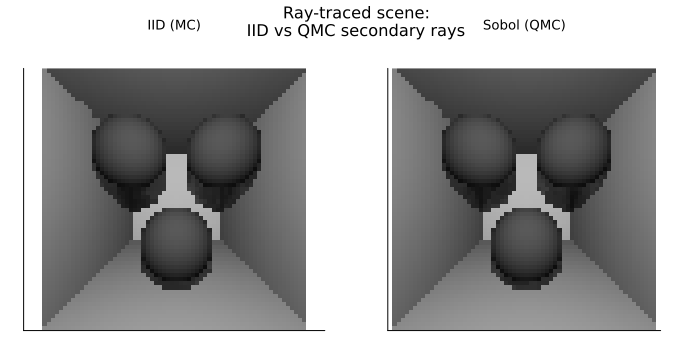

In [5]:
if HAVE_PLOTS
    # Convert 3×px×px (channels,x,y) → px×px grayscale for display
    px_sz = size(img_iid, 2)
    gray_iid = dropdims(mean(img_iid, dims=1), dims=1)   # px×px
    gray_qmc = dropdims(mean(img_qmc, dims=1), dims=1)

    p1 = heatmap(gray_iid';
        color=:grays, clims=(0,1), yflip=true,
        title="IID (MC)", axis=nothing, colorbar=false,
        aspect_ratio=:equal)
    p2 = heatmap(gray_qmc';
        color=:grays, clims=(0,1), yflip=true,
        title="Sobol (QMC)", axis=nothing, colorbar=false,
        aspect_ratio=:equal)
    display(plot(p1, p2; layout=(1,2), size=(700, 360),
        suptitle="Ray-traced scene:\nIID vs QMC secondary rays"))
end


## Analysis

Compare the smoothness of the two renders by looking at the pixel-to-pixel variance in shadow regions.

In [6]:
using Statistics

function shadow_variance(img, px)
    # Look at pixels that are dim (in shadow) but not completely black
    variances = Float64[]
    for i in 2:px-1, j in 2:px-1
        b = sum(img[:, i, j]) / 3
        if 0.01 < b < 0.3  # shadow region
            # Local variance with neighbors
            neighbors = [sum(img[:, i+di, j+dj])/3
                        for di in -1:1, dj in -1:1]
            push!(variances, var(neighbors))
        end
    end
    return isempty(variances) ? 0.0 : mean(variances)
end

v_iid = shadow_variance(img_iid, 64)
v_qmc = shadow_variance(img_qmc, 64)
println("Shadow region local variance:")
println("  IID: \$(round(v_iid, sigdigits=3))")
println("  QMC: \$(round(v_qmc, sigdigits=3))")
if v_qmc < v_iid
    println("  QMC has \$(round(v_iid/max(v_qmc, 1e-10), digits=1))× smoother shadows")
end

Shadow region local variance:
  IID: $(round(v_iid, sigdigits=3))
  QMC: $(round(v_qmc, sigdigits=3))
